In [1]:
!pip install pandas

In [2]:
!pip install matplotlib

In [3]:
import matplotlib.pyplot as plt

In [4]:
!pip install seaborn

In [5]:
import seaborn as sns

In [6]:
import pandas as pd

In [7]:
df=pd.read_csv(r"C:\Users\munug\Downloads\API_SP.POP.TOTL_DS2_en_csv_v2_207128\API_SP.POP.TOTL_DS2_en_csv_v2_207128.csv", skiprows=4)

In [8]:
df.head()

,Country Name,Country Code,Indicator Name,Indicator Code,1960,1961,1962,1963,1964,1965,...,2017,2018,2019,2020,2021,2022,2023,2024,2025,Unnamed: 70
0,Aruba,ABW,"Population, total",SP.POP.TOTL,54922.0,55578.0,56320.0,57002.0,57619.0,58190.0,...,108735.0,108908.0,109203.0,108587.0,107700.0,107310.0,107359.0,107995.0,NaN,NaN
1,Africa Eastern and Southern,AFE,"Population, total",SP.POP.TOTL,130075728.0,133534923.0,137171659.0,140945536.0,144904094.0,149033472.0,...,640058741.0,657801085.0,675950189.0,694446100.0,713090928.0,731821393.0,750491370.0,769280888.0,NaN,NaN
2,Afghanistan,AFG,"Population, total",SP.POP.TOTL,9035043.0,9214083.0,9404406.0,9604487.0,9814318.0,10036008.0,...,35688935.0,36743039.0,37856121.0,39068979.0,40000412.0,40578842.0,41454761.0,42647492.0,NaN,NaN
3,Africa Western and Central,AFW,"Population, total",SP.POP.TOTL,97630925.0,99706674.0,101854756.0,104089175.0,106388440.0,108772632.0,...,440882906.0,452195915.0,463365429.0,474569351.0,485920997.0,497387180.0,509398589.0,521764076.0,NaN,NaN
4,Angola,AGO,"Population, total",SP.POP.TOTL,5231654.0,5301583.0,5354310.0,5408320.0,5464187.0,5521981.0,...,30234839.0,31297155.0,32375632.0,33451132.0,34532429.0,35635029.0,36749906.0,37885849.0,NaN,NaN


In [9]:
print(df.columns)

Index(['Country Name', 'Country Code', 'Indicator Name', 'Indicator Code',
       '1960', '1961', '1962', '1963', '1964', '1965', '1966', '1967', '1968',
       '1969', '1970', '1971', '1972', '1973', '1974', '1975', '1976', '1977',
       '1978', '1979', '1980', '1981', '1982', '1983', '1984', '1985', '1986',
       '1987', '1988', '1989', '1990', '1991', '1992', '1993', '1994', '1995',
       '1996', '1997', '1998', '1999', '2000', '2001', '2002', '2003', '2004',
       '2005', '2006', '2007', '2008', '2009', '2010', '2011', '2012', '2013',
       '2014', '2015', '2016', '2017', '2018', '2019', '2020', '2021', '2022',
       '2023', '2024', '2025', 'Unnamed: 70'],
      dtype='str')


In [10]:
df = df.drop(['Country Code', 'Indicator Name', 'Indicator Code'], axis=1)

In [11]:
df = df.set_index('Country Name')
df = df.stack().reset_index()
df.columns = ['Country Name', 'Year', 'Population']
print(df.head())

  Country Name  Year  Population
0        Aruba  1960     54922.0
1        Aruba  1961     55578.0
2        Aruba  1962     56320.0
3        Aruba  1963     57002.0
4        Aruba  1964     57619.0


In [12]:
print(df.columns)
print(df['Country Name'].unique())

Index(['Country Name', 'Year', 'Population'], dtype='str')
<StringArray>
[                      'Aruba', 'Africa Eastern and Southern',
                 'Afghanistan',  'Africa Western and Central',
                      'Angola',                     'Albania',
                     'Andorra',                  'Arab World',
        'United Arab Emirates',                   'Argentina',
 ...
       'Virgin Islands (U.S.)',                    'Viet Nam',
                     'Vanuatu',                       'World',
                       'Samoa',                      'Kosovo',
                 'Yemen, Rep.',                'South Africa',
                      'Zambia',                    'Zimbabwe']
Length: 266, dtype: str


In [13]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 17822 entries, 0 to 17821
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Country Name  17822 non-null  str    
 1   Year          17822 non-null  str    
 2   Population    17195 non-null  float64
dtypes: float64(1), str(2)
memory usage: 417.8 KB


In [14]:
df=df.dropna()
df['Year']=df['Year'].astype(int)

In [17]:
df.columns = df.columns.str.strip()

In [20]:
for col in df.columns:
    print(repr(col))

'Country Name'
'Year'
'Population'


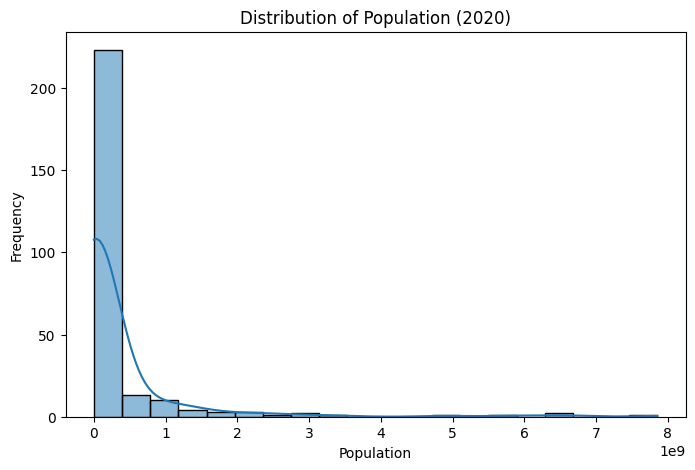

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

# Filter only 2020 data
df_2020 = df[df['Year'] == 2020]

# Remove missing values
df_2020 = df_2020.dropna()

# Plot histogram
plt.figure(figsize=(8,5))
sns.histplot(df_2020['Population'], bins=20, kde=True)

plt.title("Distribution of Population (2020)")
plt.xlabel("Population")
plt.ylabel("Frequency")

plt.show()

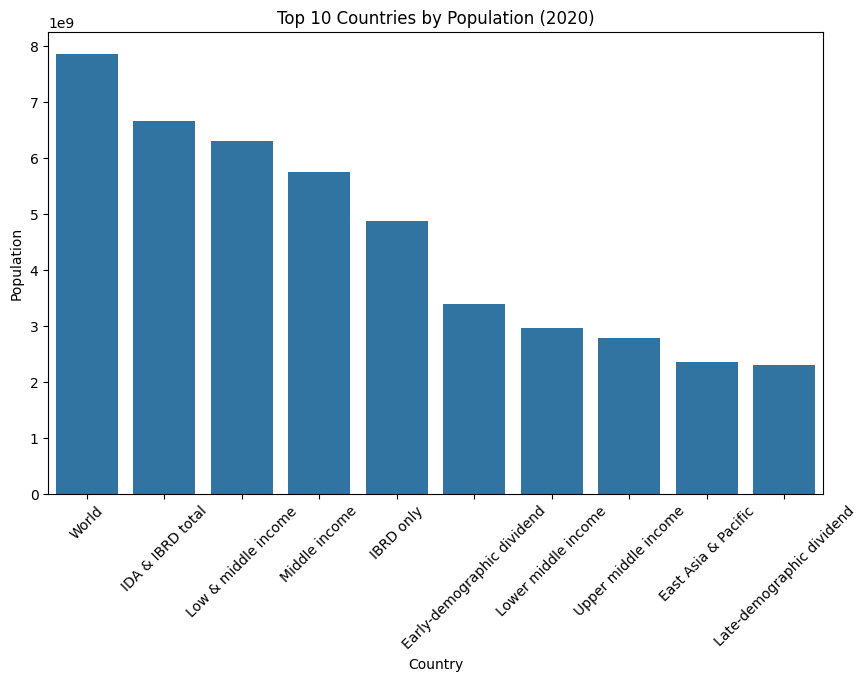

In [22]:
# Get top 10 countries by population
top10 = df_2020.sort_values(by='Population', ascending=False).head(10)

# Plot bar chart
plt.figure(figsize=(10,6))
sns.barplot(x='Country Name', y='Population', data=top10)

plt.xticks(rotation=45)
plt.title("Top 10 Countries by Population (2020)")
plt.xlabel("Country")
plt.ylabel("Population")

plt.show()